In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('../data/Superstore.csv', encoding='latin-1')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
print(df.shape)
print(df.columns.tolist())

# Transform Data Types

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(df.dtypes)

(9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


In [7]:
# Rename columns for sql compatibility

df.columns = df.columns.str.replace(' ', '_').str.lower()
df.columns = df.columns.str.replace('-', '_').str.lower()

print(df.columns.tolist())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


In [5]:
print(df['profit'].describe())

count    9994.000000
mean       28.656896
std       234.260108
min     -6599.978000
25%         1.728750
50%         8.666500
75%        29.364000
max      8399.976000
Name: profit, dtype: float64


In [6]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# Check for null values in the dataset
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

### Get all Negative Profit Count

In [8]:
df['profit'][df['profit'] < 0].count()

np.int64(1871)

In [8]:
negative_profits = df.query("profit < 0")
negative_profits.loc[:, ['order_id', 'product_name', 'profit', 'discount']].head()

,order_id,product_name,profit,discount
3,US-2015-108966,Bretford CR4500 Series Slim Rectangular Table,-383.0310,0.45
14,US-2015-118983,Holmes Replacement Filter for HEPA Air Cleaner...,-123.8580,0.80
15,US-2015-118983,Storex DuraTech Recycled Plastic Frosted Binders,-3.8160,0.80
23,US-2017-156909,"Global Deluxe Stacking Chair, Gray",-1.0196,0.30
27,US-2015-150630,"Riverside Palais Royal Lawyers Bookcase, Royal...",-1665.0522,0.50


In [9]:
df['city'].isna().sum()

np.int64(0)

### Profit from each country



In [10]:
df.groupby(['region']).agg(
    total_profit=pd.NamedAgg(column='profit', aggfunc='sum'),
    average_profit=pd.NamedAgg(column='profit', aggfunc='mean'),
    order_count=pd.NamedAgg(column='order_id', aggfunc='count')
).reset_index()

,region,total_profit,average_profit,order_count
0,Central,39706.3625,17.092709,2323
1,East,91522.7800,32.135808,2848
2,South,46749.4303,28.857673,1620
3,West,108418.4489,33.849032,3203


In [11]:
# Derive useful columns
df['profit_margin'] = (df['profit'] / df['sales']) * 100
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_qarter'] = df['order_date'].dt.quarter
df['days_to_ship'] = (df['ship_date'] - df['order_date']).dt.days

In [ ]:
# Check for issues
print("Nulls: ", df.isna().sum().sum())
print("Duplicates: ", df.duplicated().sum())
print("Negative profit: ", df[df['profit'] < 0].shape[0])

Hulls:  0
Duplicates:  0
Negative profit:  1871


Check the correlation between profit and discount

In [15]:
df[df['Discount'] == 0.7]['Profit'].min()

np.float64(-6599.978)

<Axes: xlabel='Discount', ylabel='Profit'>

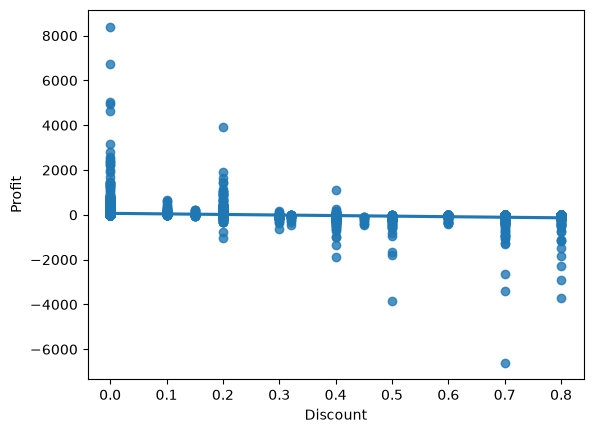

In [12]:
sns.regplot(data=df, x='Discount', y='Profit')

<Axes: xlabel='Discount', ylabel='Profit'>

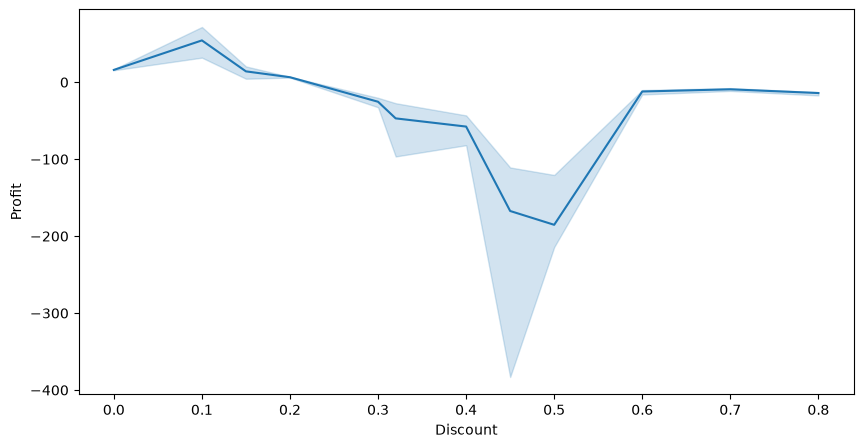

In [5]:
# Shows the drop in profit clearly
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Discount', y='Profit', estimator=np.median)

In [9]:
df[['Profit', 'Discount']].corr(method='spearman')

,Profit,Discount
Profit,1.00000,-0.54335
Discount,-0.54335,1.00000


### Regression Models

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [71]:
X = df[['Discount']]
y = df['Profit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=3
)

lm = LinearRegression()
lm.fit(X_train, y_train)

y_pred = lm.predict(X_test)

In [72]:
print(f"Intercept (b0): {lm.intercept_:.2f}")
print(f"Slope Coefficient (b1): {lm.coef_[0]:.2f}")

# Equation: Profit = Intercept + Slope * Discount

Intercept (b0): 67.02
Slope Coefficient (b1): -253.34


In [73]:
# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score (R²): {r2:.4f}")

Mean Absolute Error (MAE): 69.79
Root Mean Squared Error (RMSE): 263.85
R-squared Score (R²): 0.0332


c:\Users\91460\Desktop\Superstore Analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


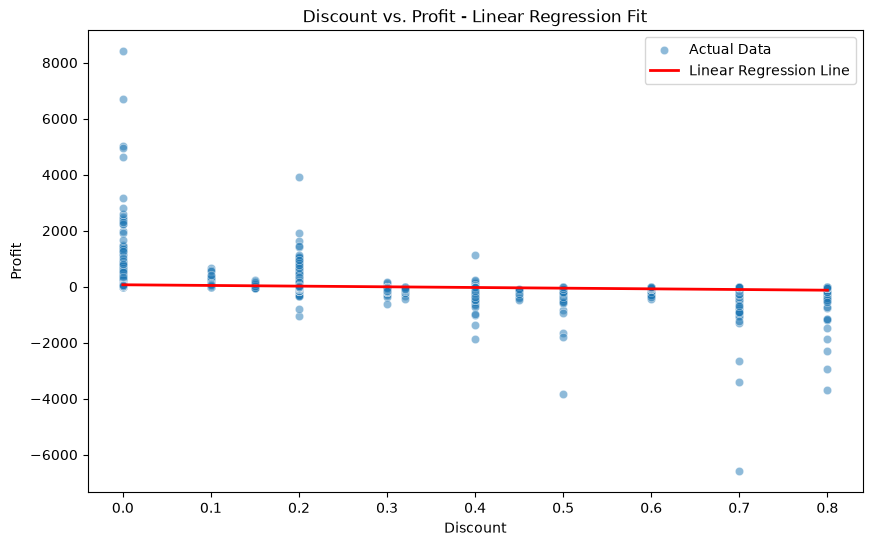

In [5]:
plt.figure(figsize=(10, 6))

# Plot actual data points
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.5, label='Actual Data')

# Plot regression line across the full discount range
X_range = np.linspace(df['Discount'].min(), df['Discount'].max(), 100).reshape(-1, 1)
X_range
y_range_pred = lm.predict(X_range)

plt.plot(X_range, y_range_pred, color='red', linewidth=2, label='Linear Regression Line')

plt.title('Discount vs. Profit - Linear Regression Fit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.legend()
plt.show()

In [68]:
Z = df[['Discount', 'Sales', 'Quantity']]
y = df['Profit']

X_train, X_test, y_train, y_test = train_test_split(
    Z, y, test_size=0.2, random_state=3
)

lm = LinearRegression()
lm.fit(X_train, y_train)

y_pred = lm.predict(X_test)

In [69]:
print(f"Intercept (b0): {lm.intercept_:.2f}")
print(f"Coefficients: {lm.coef_}")

Intercept (b0): 37.58
Coefficients: [-2.44045188e+02  1.36845821e-01 -9.52807253e-01]


In [70]:
# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.4f}")


Mean Absolute Error (MAE): 56.65
Root Mean Squared Error (RMSE): 198.85
R-squared (R²): 0.4509


In [13]:
# save cleaned csv

df.to_csv('../data/superstore_cleaned.csv', index=False)


In [3]:
print(df.shape)        # should be around (9994, 21)
print(df.memory_usage(deep=True).sum() / 1e6, "MB")  

(9994, 21)
9.653723 MB


In [16]:
import sqlite3

In [17]:
df = pd.read_csv('../data/superstore_cleaned.csv')
conn = sqlite3.connect('sales.db')
df.to_sql('orders', conn, if_exists='replace', index=False)

9994